# Intraday Curve Dimension Reduction: PCA vs. Nonlinear Methods

This notebook implements the core research idea:

> Treat each stock/day as an **intraday curve** (volume curve, volatility curve, liquidity curve) and compare **PCA** with **nonlinear methods** (Isomap, LLE, Kernel PCA, t-SNE, UMAP, Spectral Embedding / Diffusion Maps) to see whether nonlinear methods find additional structure.

## Data sources
- **Trades:** `EQY_US_ALL_TRADE_20260102.gz` — consolidated full-day trades, 17 liquid tickers
- **BBO quotes:** `EQY_US_TAQ_NYSE_BBO_1_20231002.gz` — NYSE venue BBO, hour 1

## Curve types we build
| Curve | Source | Description |
|---|---|---|
| Volume curve | Trades | Log volume per minute (390-dim) |
| Volatility curve | Trades | Realized variance per minute |
| Trade-count curve | Trades | Number of prints per minute |
| Spread curve | BBO | Average spread (bps) per minute |
| Depth curve | BBO | Total quoted depth per minute |
| Depth-imbalance curve | BBO | (bid_sz - ask_sz) / (bid_sz + ask_sz) per minute |

## DR methods we compare
| Method | Type |
|---|---|
| PCA | Linear |
| Kernel PCA (RBF) | Nonlinear (kernel) |
| Isomap | Nonlinear (geodesic) |
| LLE | Nonlinear (local linear) |
| Spectral Embedding | Nonlinear (diffusion / Laplacian) |
| t-SNE | Nonlinear (probabilistic) |
| UMAP | Nonlinear (graph-based) |

In [20]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['PYTHONWARNINGS'] = 'ignore'

from pathlib import Path
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding, TSNE, MDS, trustworthiness
import umap

DATA_DIR = Path('../data/nyse_taq_samples')
TRADE_PATH = DATA_DIR / 'EQY_US_ALL_TRADE_20260102.gz'
BBO_PATH = DATA_DIR / 'EQY_US_TAQ_NYSE_BBO_1_20231002.gz'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

print('Trade file:', TRADE_PATH.exists())
print('BBO file:', BBO_PATH.exists())

Trade file: True
BBO file: True


## 1. Build trade-minute bars

Stream the consolidated trade file and aggregate into symbol-minute OHLCV bars.

In [6]:
target_symbols = {
    'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA', 'META', 'NVDA',
    'SPY', 'QQQ', 'IWM', 'DIA', 'VXX',
    'JPM', 'XOM', 'JNJ', 'UNH', 'HD', 'PG'
}

def parse_time_ns(time_str):
    try:
        return int(str(time_str)[:2]) * 60 + int(str(time_str)[2:4])
    except Exception:
        return np.nan

def build_trade_bars_fast(path, target_symbols):
    """Use gzip -dc | grep pipeline for C-speed filtering, then pandas for parsing."""
    import subprocess

    abs_path = str(path.resolve())

    # Build grep pattern: |(AAPL|MSFT|TSLA|...)|
    symbol_alt = '|'.join(sorted(target_symbols))
    pattern = f'\\|({symbol_alt})\\|'

    # Pipeline: gzip -dc → grep → pandas.read_csv
    print(f'Scanning 3 GB trade file for {len(target_symbols)} symbols...')
    gz = subprocess.Popen(['gzip', '-dc', abs_path], stdout=subprocess.PIPE)
    grep = subprocess.Popen(
        ['grep', '-E', pattern],
        stdin=gz.stdout, stdout=subprocess.PIPE
    )
    gz.stdout.close()

    cols = ['Time', 'Exchange', 'Symbol', 'Sale Condition', 'Trade Volume',
            'Trade Price', 'Trade Stop Stock Indicator', 'Trade Correction Indicator',
            'Sequence Number', 'Trade Id', 'Source of Trade', 'Trade Reporting Facility',
            'Participant Timestamp', 'Trade Reporting Facility TRF Timestamp',
            'Trade Through Exempt Indicator']

    df = pd.read_csv(
        grep.stdout, sep='|', header=None, names=cols,
        usecols=['Time', 'Symbol', 'Trade Volume', 'Trade Price'],
        dtype={'Time': 'str', 'Symbol': 'str', 'Trade Volume': 'int32', 'Trade Price': 'float32'},
        on_bad_lines='skip',
    )
    grep.stdout.close()
    gz.wait()
    grep.wait()

    print(f'  grep found {len(df):,} raw rows')

    # Filter and compute
    df = df[df['Symbol'].isin(target_symbols)].copy()
    df['time_bin'] = df['Time'].apply(parse_time_ns)
    df = df.dropna(subset=['time_bin'])
    df['time_bin'] = df['time_bin'].astype(int)
    df = df[(df['Trade Volume'] > 0) & (df['Trade Price'] > 0)]

    print(f'  after filters: {len(df):,} rows, {df["Symbol"].nunique()} symbols')

    bars = df.groupby(['Symbol', 'time_bin']).agg(
        total_volume=('Trade Volume', 'sum'),
        trade_count=('Trade Volume', 'count'),
        open_price=('Trade Price', 'first'),
        high_price=('Trade Price', 'max'),
        low_price=('Trade Price', 'min'),
        close_price=('Trade Price', 'last'),
        vwap=('Trade Price', lambda x: np.average(x, weights=df.loc[x.index, 'Trade Volume'])),
    ).reset_index()

    bars = bars.rename(columns={'Symbol': 'symbol'})

    bars['minute_return'] = bars.groupby('symbol')['close_price'].transform(
        lambda x: np.log(x) - np.log(x.shift(1))
    )
    bars['minute_range'] = np.log(bars['high_price']) - np.log(bars['low_price'])
    bars['realized_var'] = bars['minute_return'] ** 2
    bars['dollar_volume'] = bars['total_volume'] * bars['vwap']
    return bars

trade_bars = build_trade_bars_fast(TRADE_PATH, target_symbols)
print(f'Trade bars: {len(trade_bars):,} rows, {trade_bars["symbol"].nunique()} symbols')
trade_bars.head()

Scanning 3 GB trade file for 18 symbols...
  grep found 10,376,320 raw rows
  after filters: 10,376,289 rows, 17 symbols
Trade bars: 14,371 rows, 17 symbols


,symbol,time_bin,total_volume,trade_count,open_price,high_price,low_price,close_price,vwap,minute_return,minute_range,realized_var,dollar_volume
0,AAPL,240,1788,75,272.170013,273.299988,272.170013,273.079987,273.176323,NaN,0.004143,NaN,488439.264801
1,AAPL,241,791,39,273.290009,273.899994,273.239990,273.500000,273.410162,0.001537,0.002412,2.361896e-06,216267.438477
2,AAPL,242,12,6,273.250000,273.320007,273.250000,273.320007,273.302500,-0.000658,0.000256,4.330104e-07,3279.630005
3,AAPL,243,66,8,273.320007,273.320007,273.299988,273.299988,273.319097,-0.000073,0.000073,5.392394e-09,18039.060425
4,AAPL,244,74,10,273.339996,273.420013,273.320007,273.399994,273.371627,0.000366,0.000366,1.337614e-07,20229.500397


## 2. Build BBO quote-minute bars

Stream the NYSE BBO file and aggregate quote updates into symbol-minute bars.

In [9]:
def parse_bbo_time(time_str):
    """Parse BBO time format HH:MM:SS.ns into minute of day."""
    try:
        s = str(time_str)
        return int(s[:2]) * 60 + int(s[3:5])
    except Exception:
        return np.nan

def build_bbo_bars_fast(path, target_symbols):
    """Use gzip | grep pipeline for C-speed filtering of BBO quotes."""
    import subprocess

    abs_path = str(path.resolve())
    symbol_alt = '|'.join(sorted(target_symbols))

    print(f'Scanning 1.5 GB BBO file for {len(target_symbols)} symbols...')
    gz = subprocess.Popen(['gzip', '-dc', abs_path], stdout=subprocess.PIPE)
    grep1 = subprocess.Popen(['grep', '^140,'], stdin=gz.stdout, stdout=subprocess.PIPE)
    grep2 = subprocess.Popen(
        ['grep', '-E', f',({symbol_alt}),'],
        stdin=grep1.stdout, stdout=subprocess.PIPE
    )
    gz.stdout.close()
    grep1.stdout.close()

    df = pd.read_csv(
        grep2.stdout, sep=',', header=None,
        names=['msg_type', 'seq', 'time', 'symbol', 'quote_cond',
               'bid_px', 'bid_sz', 'ask_px', 'ask_sz', 'flag', 'extra'],
        usecols=['time', 'symbol', 'bid_px', 'bid_sz', 'ask_px', 'ask_sz'],
        dtype={'time': 'str', 'symbol': 'str',
               'bid_px': 'float32', 'bid_sz': 'float32',
               'ask_px': 'float32', 'ask_sz': 'float32'},
        on_bad_lines='skip',
    )
    grep2.stdout.close()
    gz.wait()
    grep1.wait()
    grep2.wait()

    print(f'  grep found {len(df):,} raw quote rows')

    df = df[df['symbol'].isin(target_symbols)].copy()
    df['time_bin'] = df['time'].apply(parse_bbo_time)
    df = df.dropna(subset=['time_bin'])
    df['time_bin'] = df['time_bin'].astype(int)
    # Both sides must be present; don't require ask >= bid (crossed quotes
    # are normal in pre-market)
    df = df[(df['bid_px'] > 0) & (df['ask_px'] > 0)]

    print(f'  after filters: {len(df):,} rows, {df["symbol"].nunique()} symbols')

    df['mid'] = (df['bid_px'] + df['ask_px']) / 2
    df['spread'] = (df['ask_px'] - df['bid_px']).abs()
    df['spread_bps'] = df['spread'] / df['mid'] * 10000
    df['total_depth'] = df['bid_sz'] + df['ask_sz']
    df['depth_imbalance'] = (df['bid_sz'] - df['ask_sz']) / (df['bid_sz'] + df['ask_sz'])

    bars = df.groupby(['symbol', 'time_bin']).agg(
        quote_count=('mid', 'count'),
        avg_spread_bps=('spread_bps', 'mean'),
        avg_total_depth=('total_depth', 'mean'),
        avg_depth_imbalance=('depth_imbalance', 'mean'),
        avg_mid=('mid', 'mean'),
    ).reset_index()
    return bars

bbo_bars = build_bbo_bars_fast(BBO_PATH, target_symbols)
print(f'BBO bars: {len(bbo_bars):,} rows, {bbo_bars["symbol"].nunique()} symbols')
bbo_bars.head()

Scanning 1.5 GB BBO file for 18 symbols...
  grep found 6,992,976 raw quote rows
  after filters: 6,987,348 rows, 8 symbols
BBO bars: 3,516 rows, 8 symbols


,symbol,time_bin,quote_count,avg_spread_bps,avg_total_depth,avg_depth_imbalance,avg_mid
0,AAPL,468,1,126.442352,200.0,0.0,172.410004
1,AAPL,470,2,123.525093,200.0,0.0,172.434998
2,AAPL,476,1,117.691330,200.0,0.0,172.485001
3,AAPL,480,2,113.609985,200.0,0.0,172.519989
4,AAPL,502,1,139.876587,200.0,0.0,172.294998


## 3. Construct intraday curves

Each curve is a matrix where **rows = symbols** and **columns = minutes of day**. We build six curve types.

In [10]:
def build_curve_matrix(bars, value_col, index_col='symbol', col_col='time_bin', transform='log1p'):
    """Pivot bars into a symbol × minute matrix and apply transform."""
    mat = bars.pivot_table(index=index_col, columns=col_col, values=value_col, fill_value=0)
    if transform == 'log1p':
        mat = np.log1p(mat)
    elif transform == 'sqrt':
        mat = np.sqrt(mat.clip(lower=0))
    elif transform == 'raw':
        pass
    return mat

# Trade-side curves
volume_curve = build_curve_matrix(trade_bars, 'total_volume', transform='log1p')
volatility_curve = build_curve_matrix(trade_bars, 'realized_var', transform='log1p')
trade_count_curve = build_curve_matrix(trade_bars, 'trade_count', transform='log1p')

# Quote-side curves
spread_curve = build_curve_matrix(bbo_bars, 'avg_spread_bps', transform='log1p')
depth_curve = build_curve_matrix(bbo_bars, 'avg_total_depth', transform='log1p')
imbalance_curve = build_curve_matrix(bbo_bars, 'avg_depth_imbalance', transform='raw')

curves = {
    'Volume (trades)': volume_curve,
    'Volatility (trades)': volatility_curve,
    'Trade count (trades)': trade_count_curve,
    'Spread (BBO)': spread_curve,
    'Depth (BBO)': depth_curve,
    'Depth imbalance (BBO)': imbalance_curve,
}

for name, curve in curves.items():
    print(f'{name:30s}  shape={curve.shape}  range=[{curve.values.min():.3f}, {curve.values.max():.3f}]')

Volume (trades)                 shape=(17, 961)  range=[0.000, 16.929]
Volatility (trades)             shape=(17, 960)  range=[0.000, 0.004]
Trade count (trades)            shape=(17, 961)  range=[0.000, 10.859]
Spread (BBO)                    shape=(8, 530)  range=[0.000, 6.635]
Depth (BBO)                     shape=(8, 530)  range=[0.000, 9.442]
Depth imbalance (BBO)           shape=(8, 530)  range=[-0.926, 0.926]


## 4. Visualize the raw curves

Before any dimension reduction, let's look at the curves themselves. Each line is one symbol.

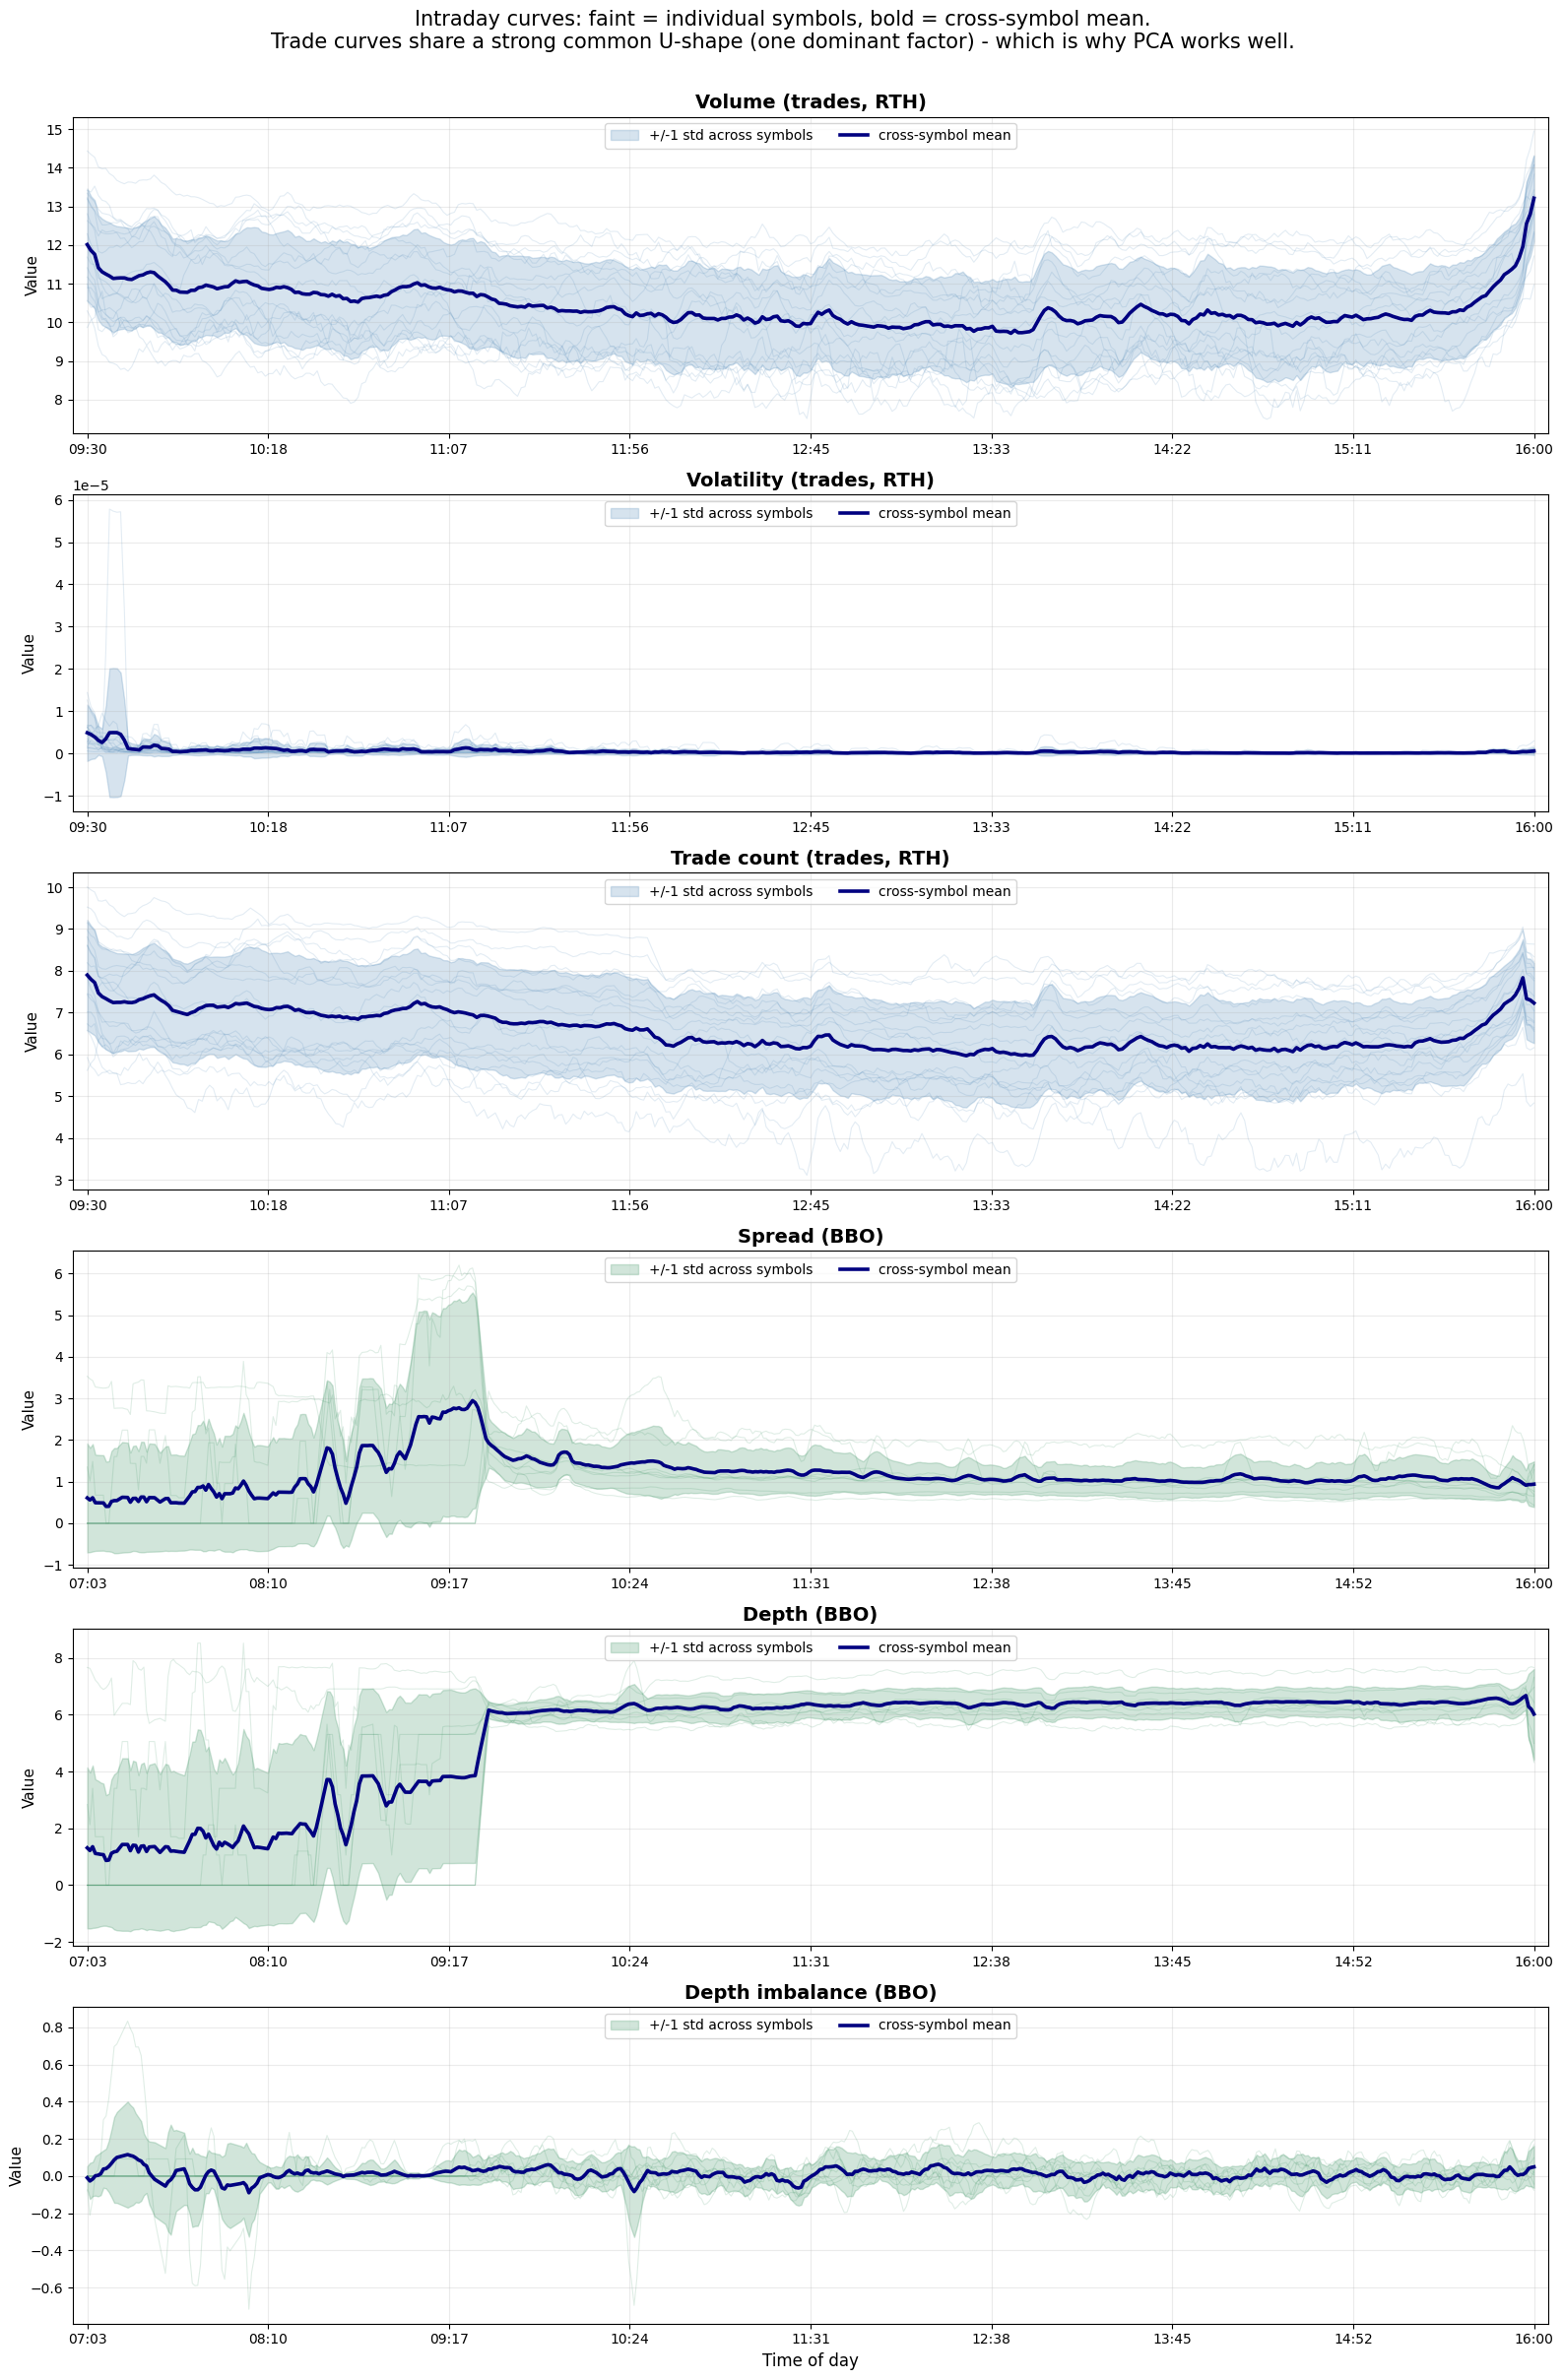

In [25]:
RTH_START, RTH_END = 570, 960  # 9:30-16:00 ET, in minutes-of-day

def minute_to_clock(m):
    m = int(m)
    return f'{m // 60:02d}:{m % 60:02d}'

def plot_curve(ax, curve, name, clip_rth=False, smooth=5, color='steelblue'):
    cols = curve.columns.values.astype(float)
    if clip_rth:
        col_mask = (cols >= RTH_START) & (cols <= RTH_END)
    else:
        # drop columns that are entirely empty (no data for any symbol)
        col_mask = (curve.values != 0).any(axis=0)
    sub = curve.loc[:, col_mask]
    x = sub.columns.values.astype(float)
    if len(x) == 0:
        ax.set_title(f'{name}  (no data in range)', fontsize=13)
        return
    vals = sub.values

    # faint individual symbol lines (lightly smoothed)
    for row in vals:
        s = pd.Series(row, index=x).rolling(smooth, min_periods=1, center=True).mean()
        ax.plot(x, s.values, color=color, alpha=0.15, lw=0.8)

    # cross-symbol mean +/- 1 std band
    mean = pd.Series(np.nanmean(vals, axis=0), index=x).rolling(smooth, min_periods=1, center=True).mean()
    std = pd.Series(np.nanstd(vals, axis=0), index=x).rolling(smooth, min_periods=1, center=True).mean()
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.22, label='+/-1 std across symbols')
    ax.plot(x, mean.values, color='navy', lw=2.6, label='cross-symbol mean')

    ax.set_title(name, fontsize=14, fontweight='bold')
    ticks = np.linspace(x.min(), x.max(), 9)
    ax.set_xticks(ticks)
    ax.set_xticklabels([minute_to_clock(t) for t in ticks])
    ax.grid(alpha=0.25)
    ax.margins(x=0.01)
    ax.set_ylabel('Value', fontsize=11)
    ax.legend(fontsize=10, loc='upper center', ncol=2)

# One full-width panel per curve: 6 rows x 1 column
fig, axes = plt.subplots(6, 1, figsize=(16, 24))

plot_curve(axes[0], curves['Volume (trades)'], 'Volume (trades, RTH)', clip_rth=True)
plot_curve(axes[1], curves['Volatility (trades)'], 'Volatility (trades, RTH)', clip_rth=True)
plot_curve(axes[2], curves['Trade count (trades)'], 'Trade count (trades, RTH)', clip_rth=True)
plot_curve(axes[3], curves['Spread (BBO)'], 'Spread (BBO)', color='seagreen')
plot_curve(axes[4], curves['Depth (BBO)'], 'Depth (BBO)', color='seagreen')
plot_curve(axes[5], curves['Depth imbalance (BBO)'], 'Depth imbalance (BBO)', color='seagreen')

axes[-1].set_xlabel('Time of day', fontsize=12)

plt.suptitle('Intraday curves: faint = individual symbols, bold = cross-symbol mean.\n'
             'Trade curves share a strong common U-shape (one dominant factor) - which is why PCA works well.',
             fontsize=15, y=1.005)
plt.tight_layout()
plt.savefig('../figures/intraday_curves_clean.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Apply dimension reduction methods

For each curve type, we apply seven DR methods and produce 2D embeddings.

In [22]:
def run_all_dr(X, n_neighbors=3):
    """Apply all DR methods and return a dict of 2D embeddings."""
    n = X.shape[0]
    nn = min(n_neighbors, n - 1)
    results = {}
    
    # PCA
    results['PCA'] = PCA(n_components=2, svd_solver='full').fit_transform(X)
    
    # Kernel PCA (RBF)
    results['Kernel PCA'] = KernelPCA(n_components=2, kernel='rbf', gamma=1/X.shape[1]).fit_transform(X)
    
    # Isomap
    results['Isomap'] = Isomap(n_neighbors=nn, n_components=2).fit_transform(X)
    
    # LLE
    results['LLE'] = LocallyLinearEmbedding(n_neighbors=nn, n_components=2, method='standard').fit_transform(X)
    
    # Spectral Embedding (approximates diffusion maps)
    results['Spectral'] = SpectralEmbedding(n_neighbors=nn, n_components=2, affinity='rbf').fit_transform(X)
    
    # t-SNE
    results['t-SNE'] = TSNE(n_components=2, perplexity=min(5, n-1), random_state=42, init='pca').fit_transform(X)
    
    # UMAP
    results['UMAP'] = umap.UMAP(n_neighbors=nn, n_components=2, random_state=42).fit_transform(X)
    
    return results

# Run DR on all curve types
all_embeddings = {}
for curve_name, curve in curves.items():
    X = StandardScaler().fit_transform(curve.values)
    all_embeddings[curve_name] = run_all_dr(X)
    print(f'Done: {curve_name}')

Done: Volume (trades)
Done: Volatility (trades)
Done: Trade count (trades)
Done: Spread (BBO)
Done: Depth (BBO)
Done: Depth imbalance (BBO)


## 6. Visualize all embeddings

Grid: rows = curve types, columns = DR methods. Each point is a symbol, labeled by ticker.

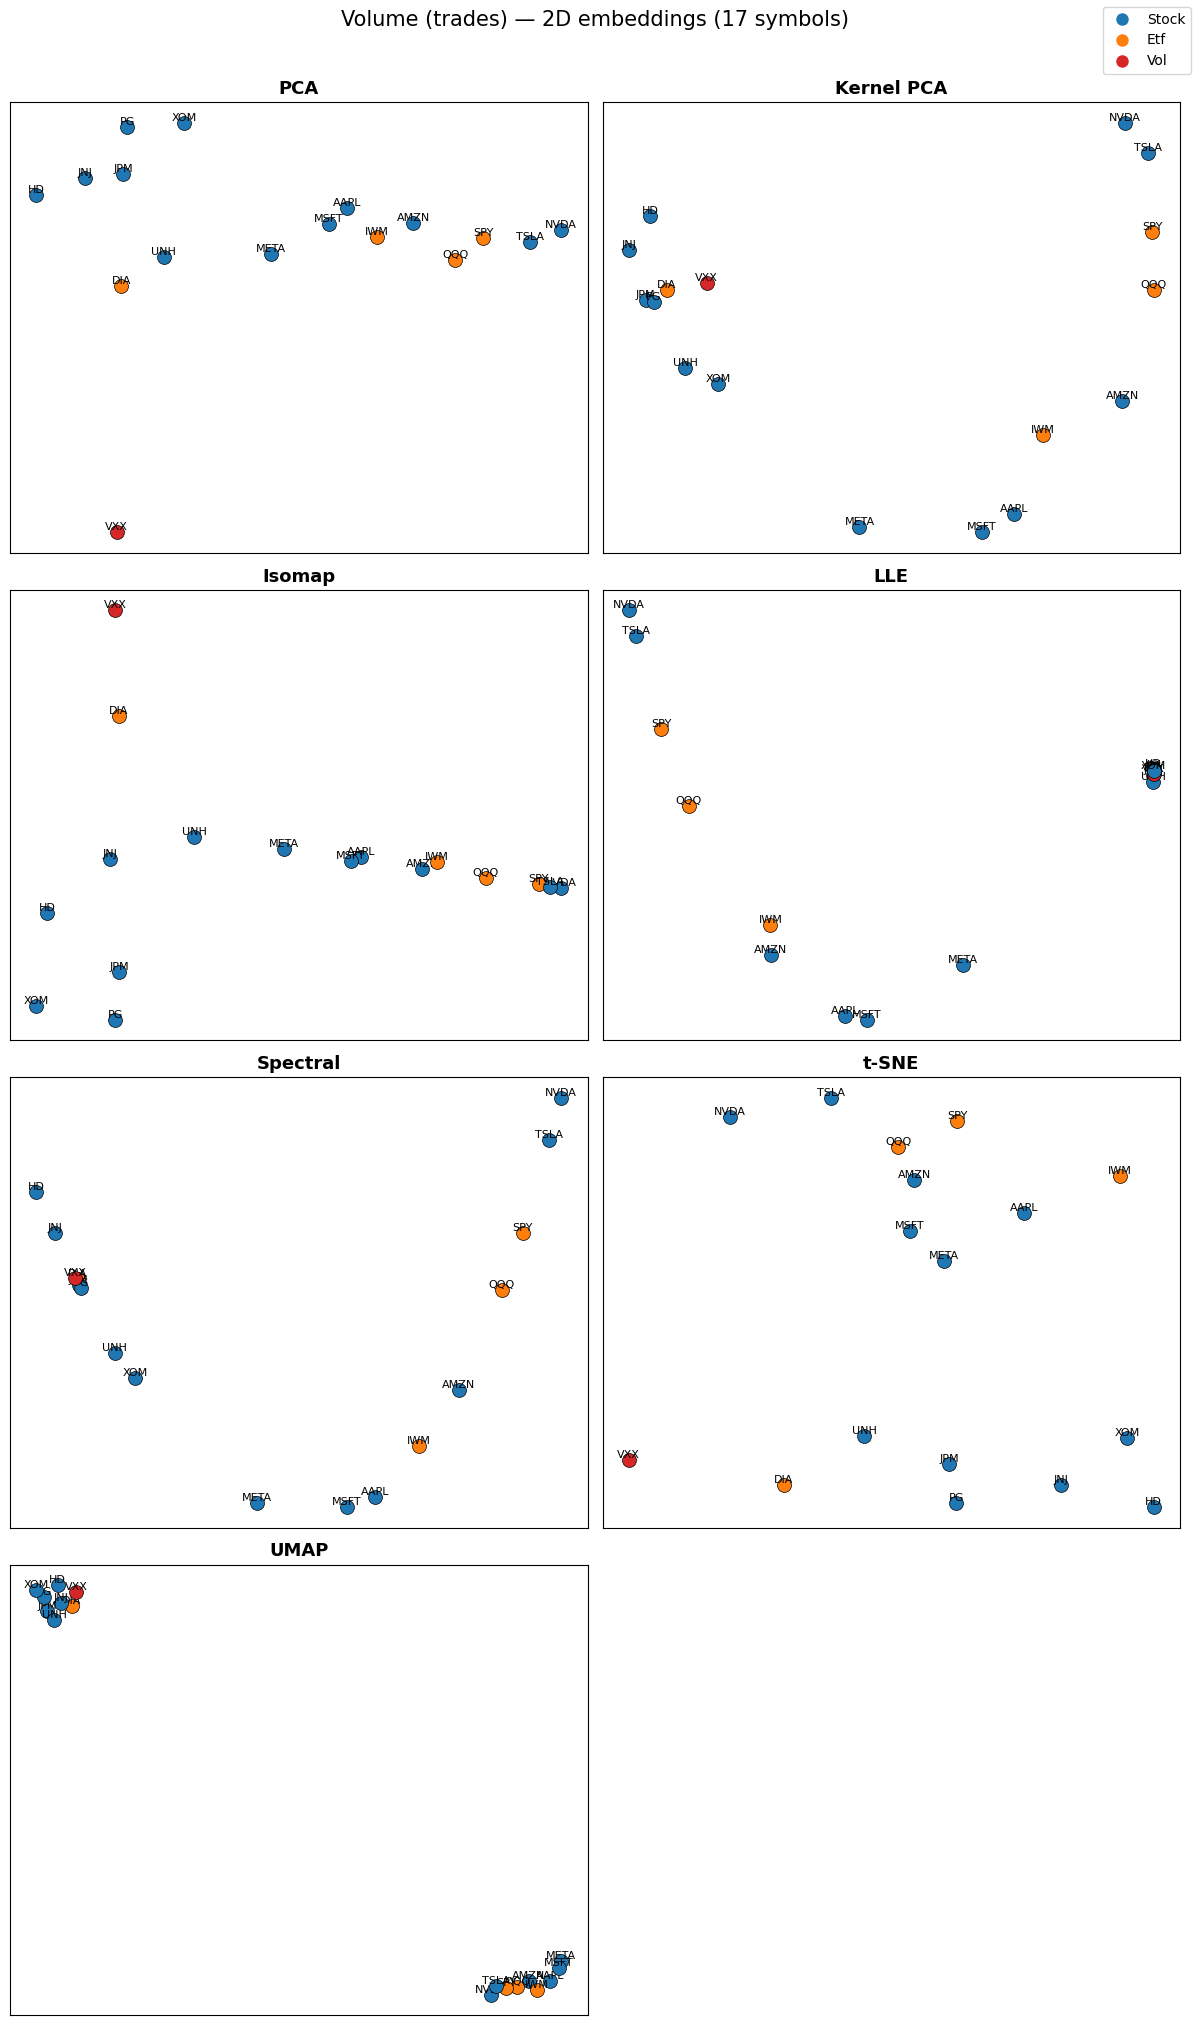

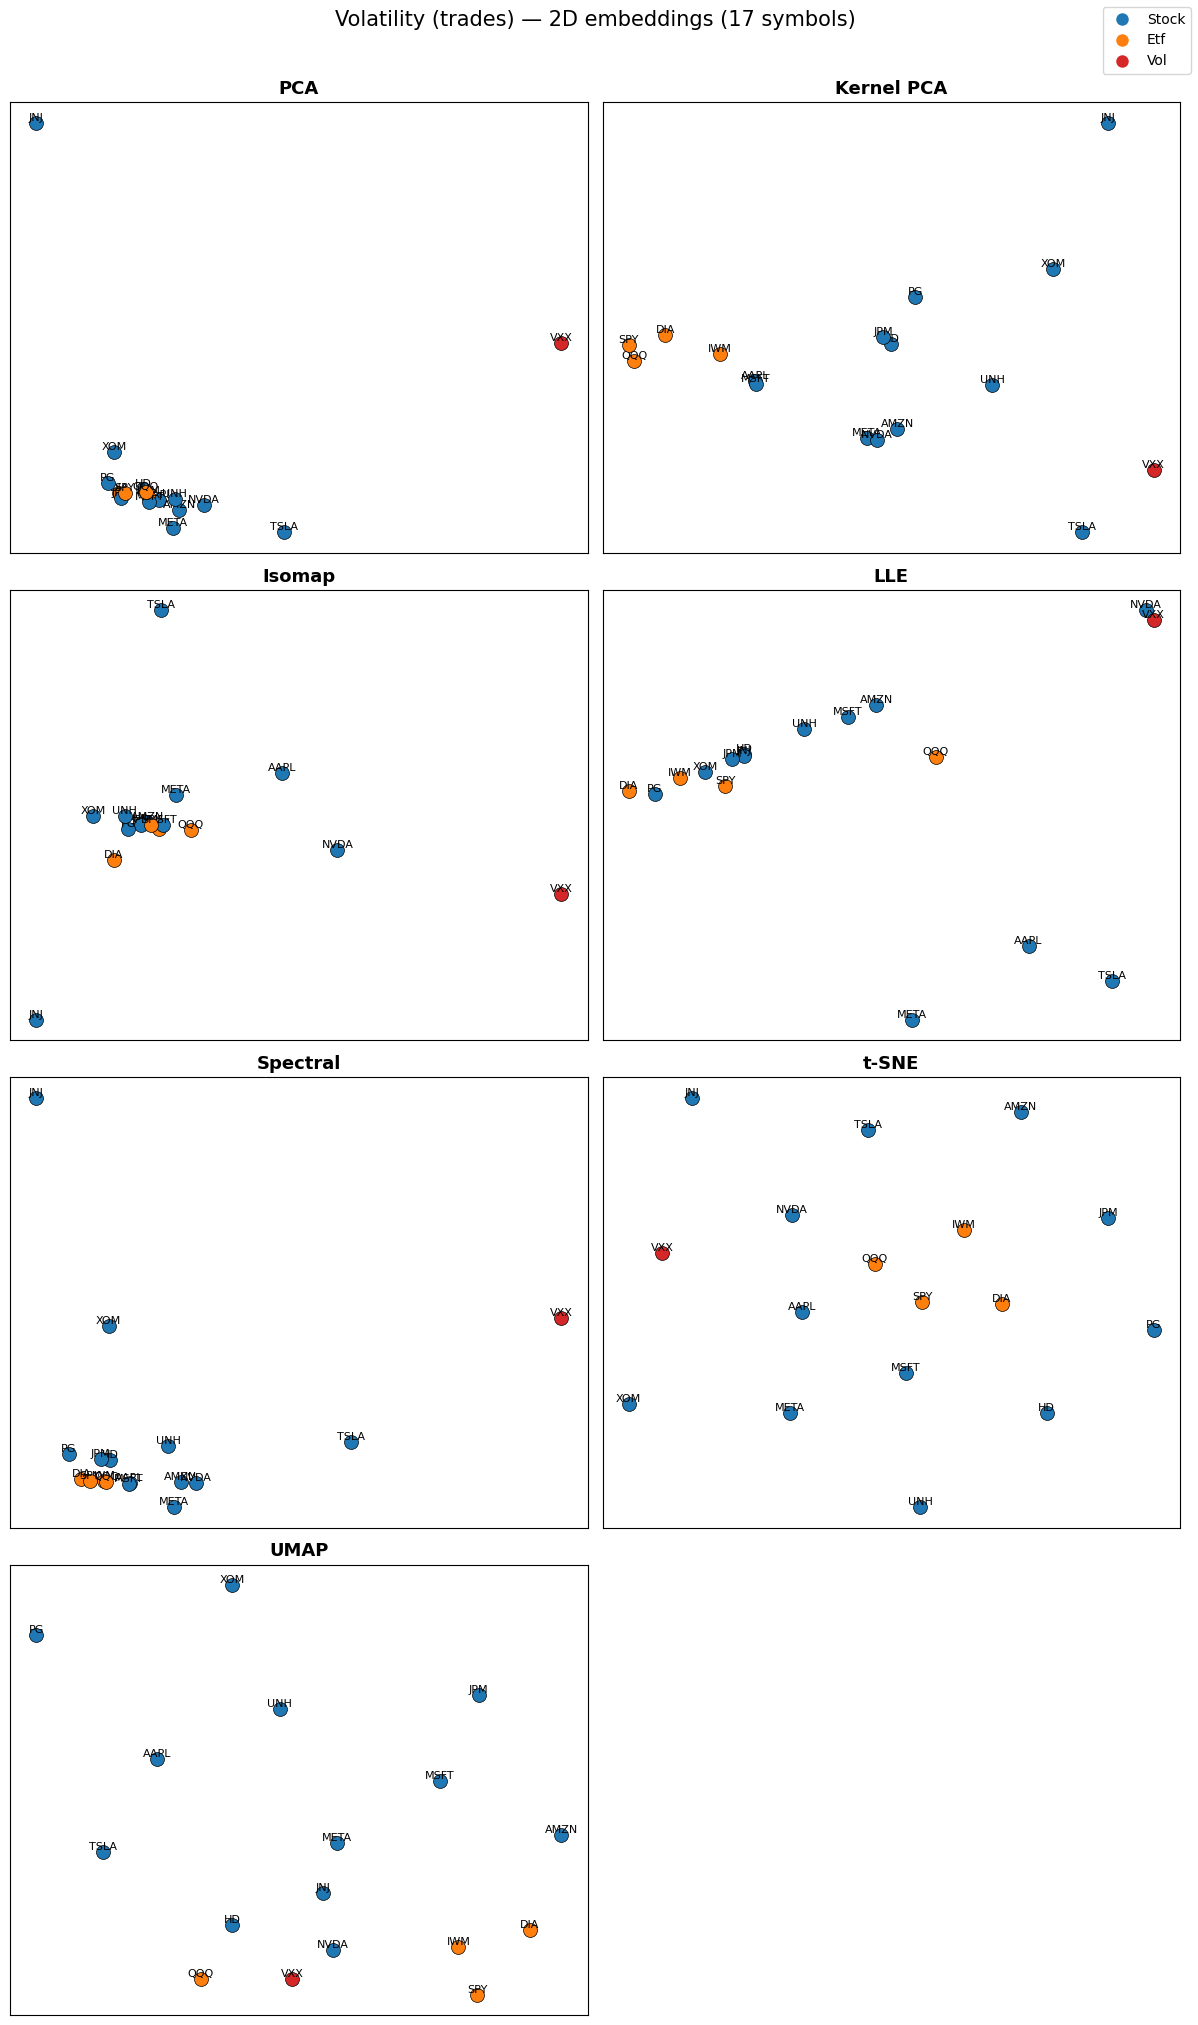

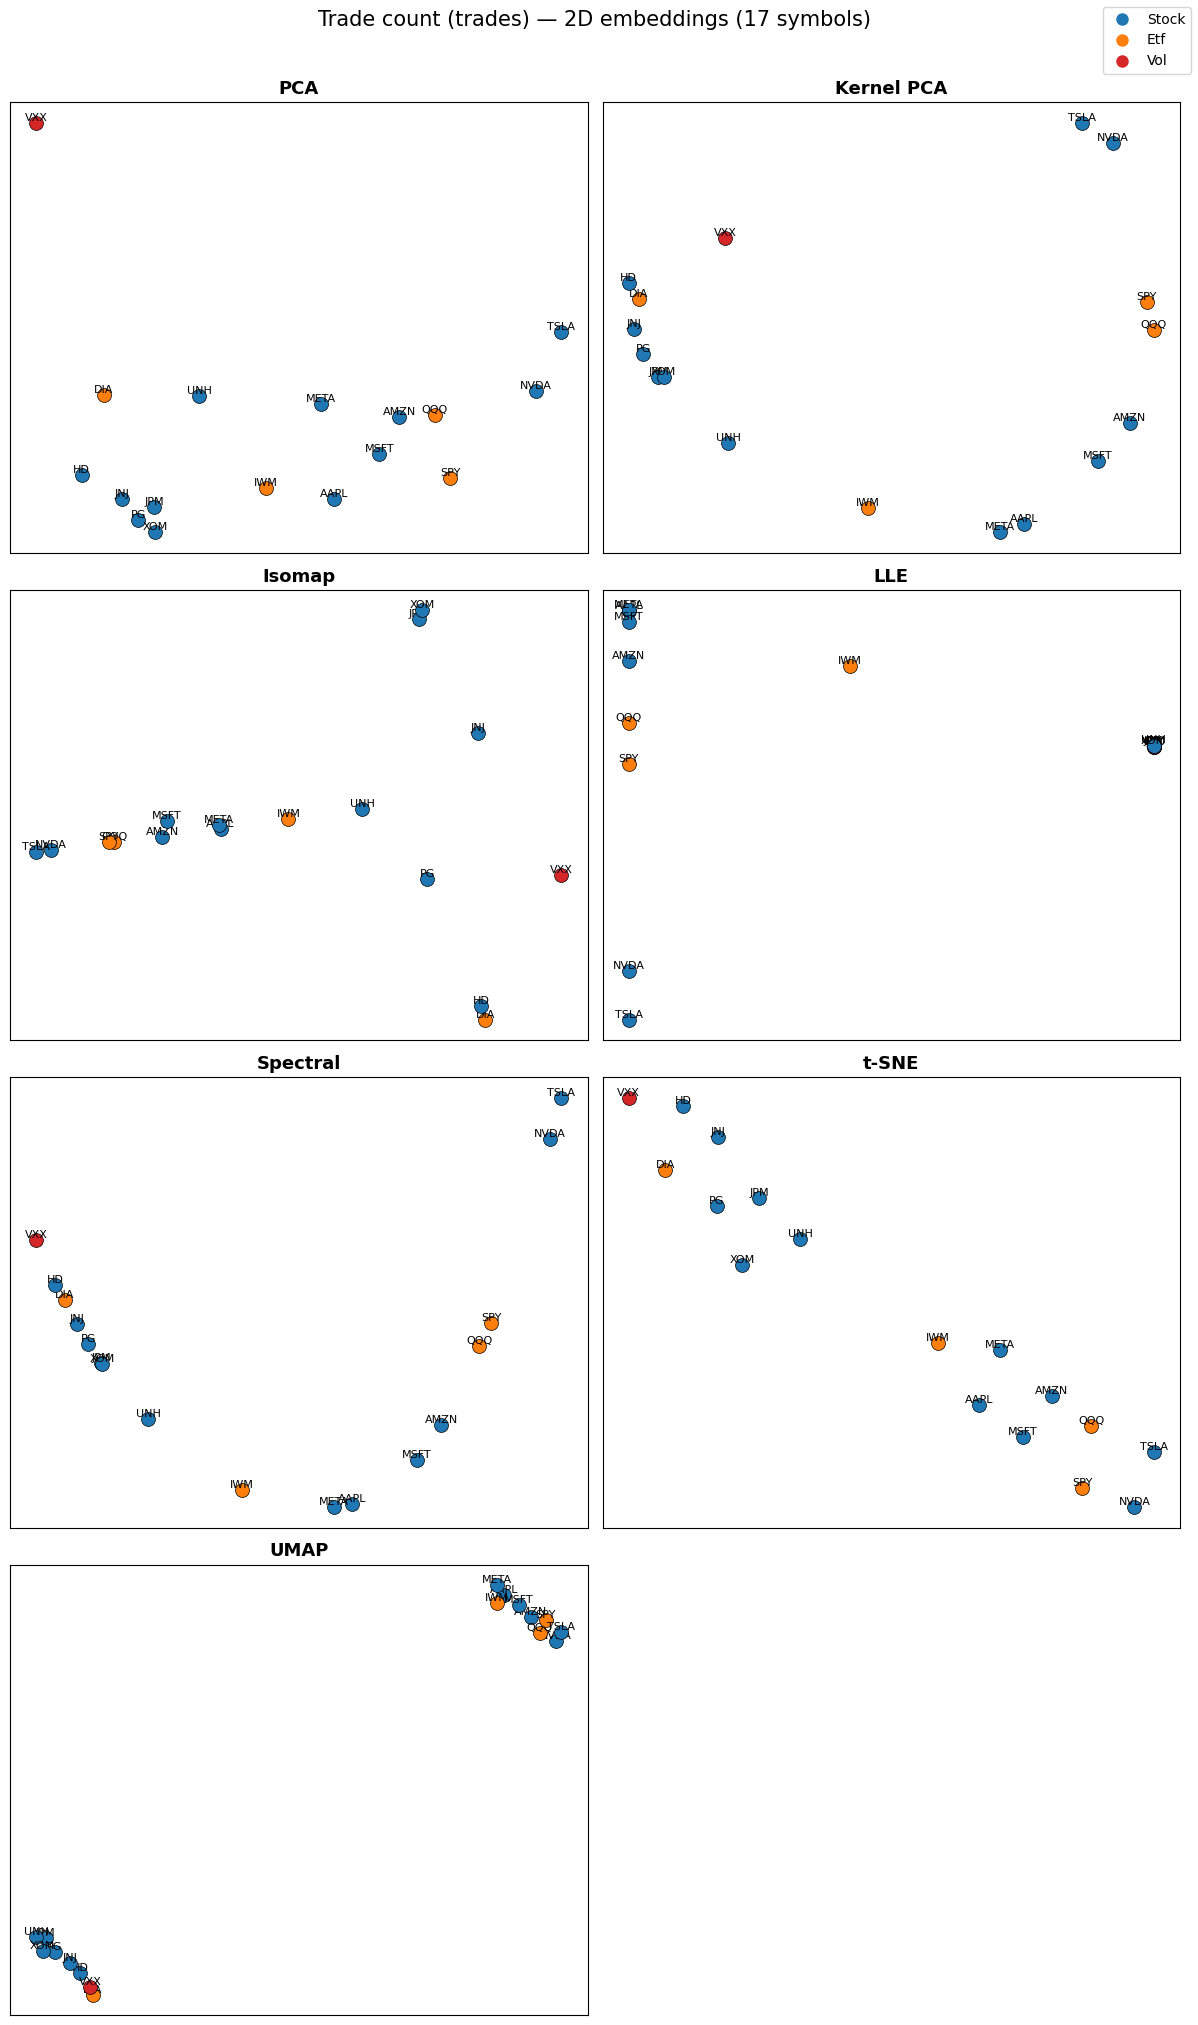

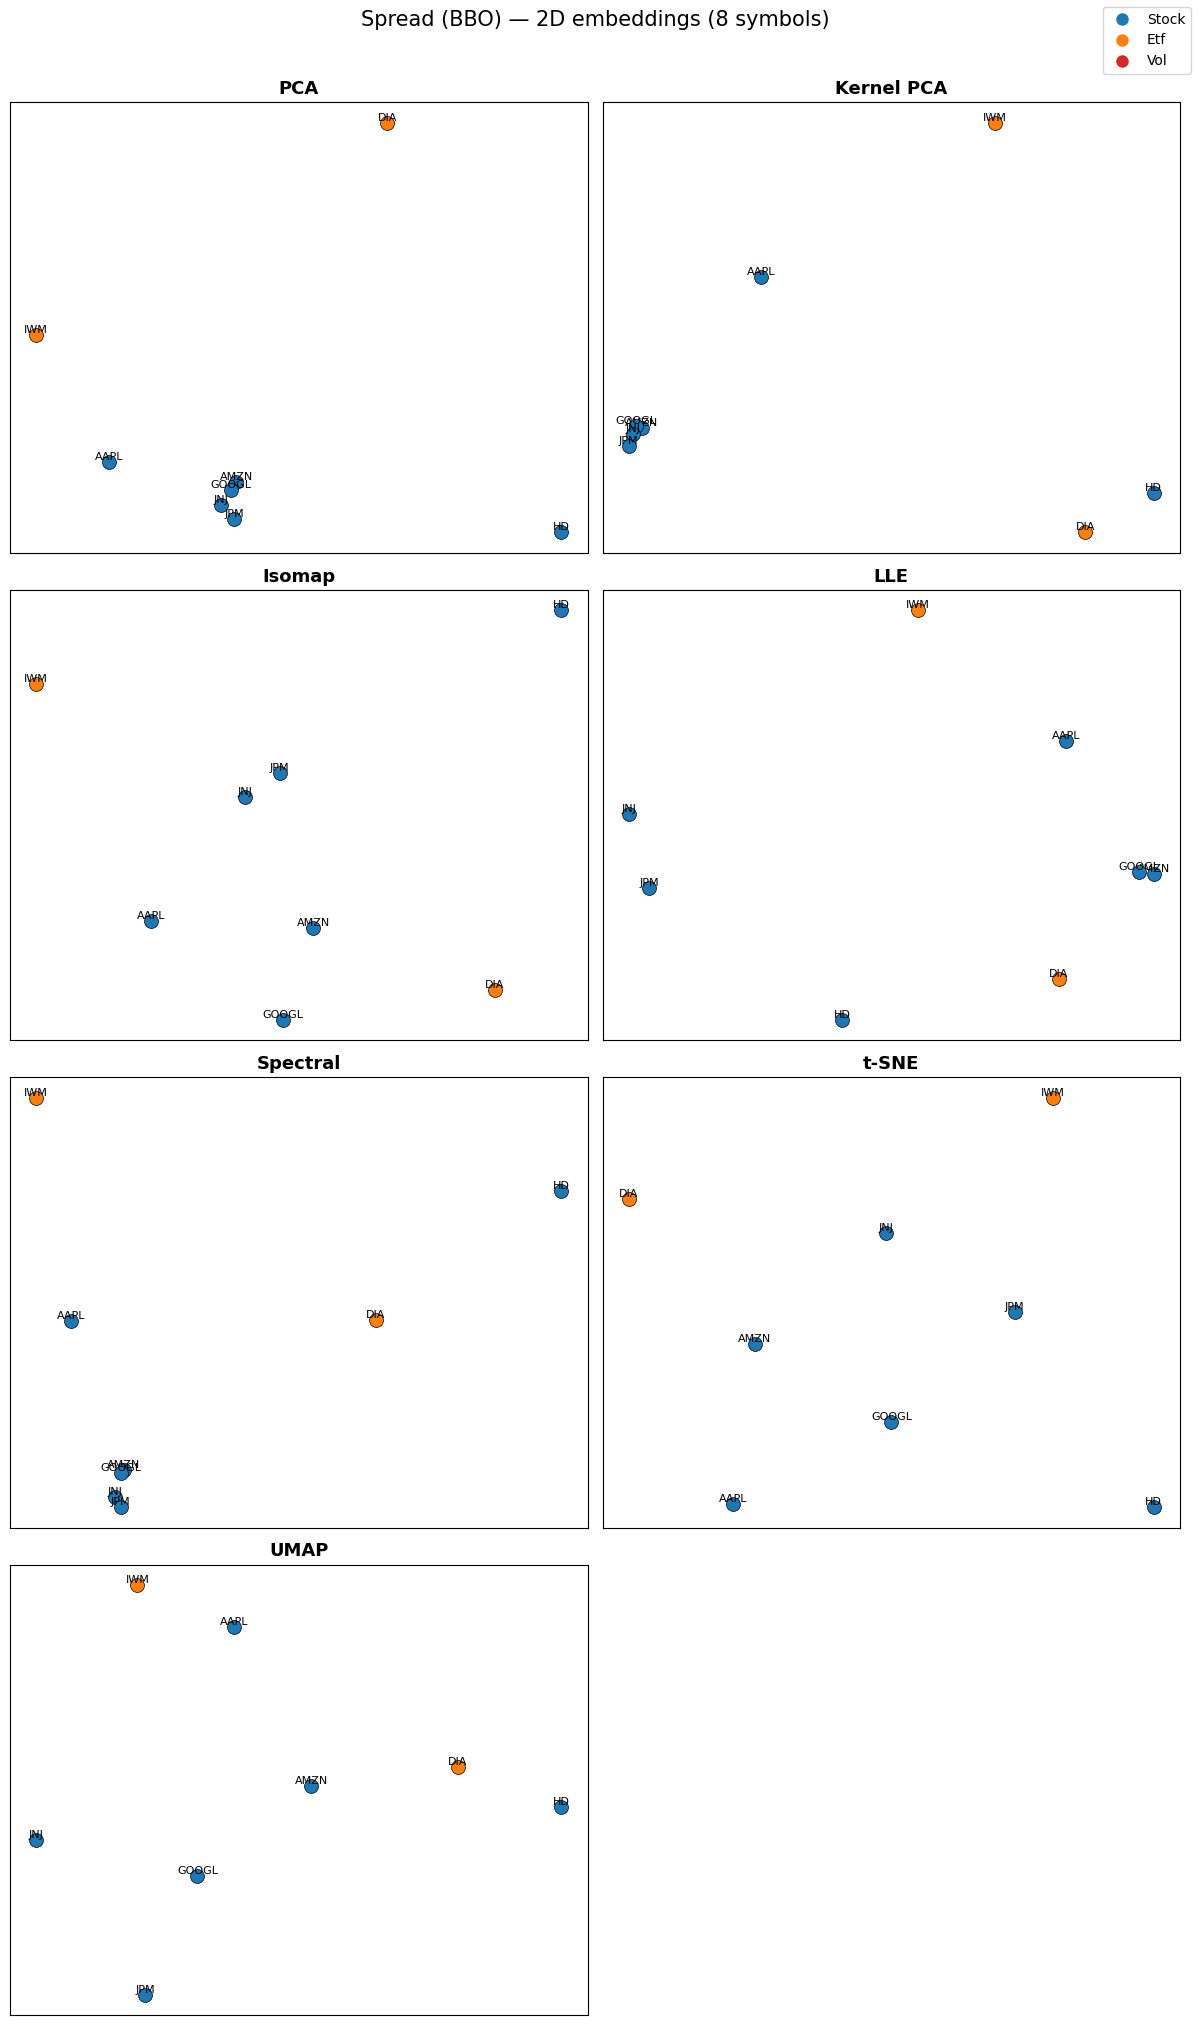

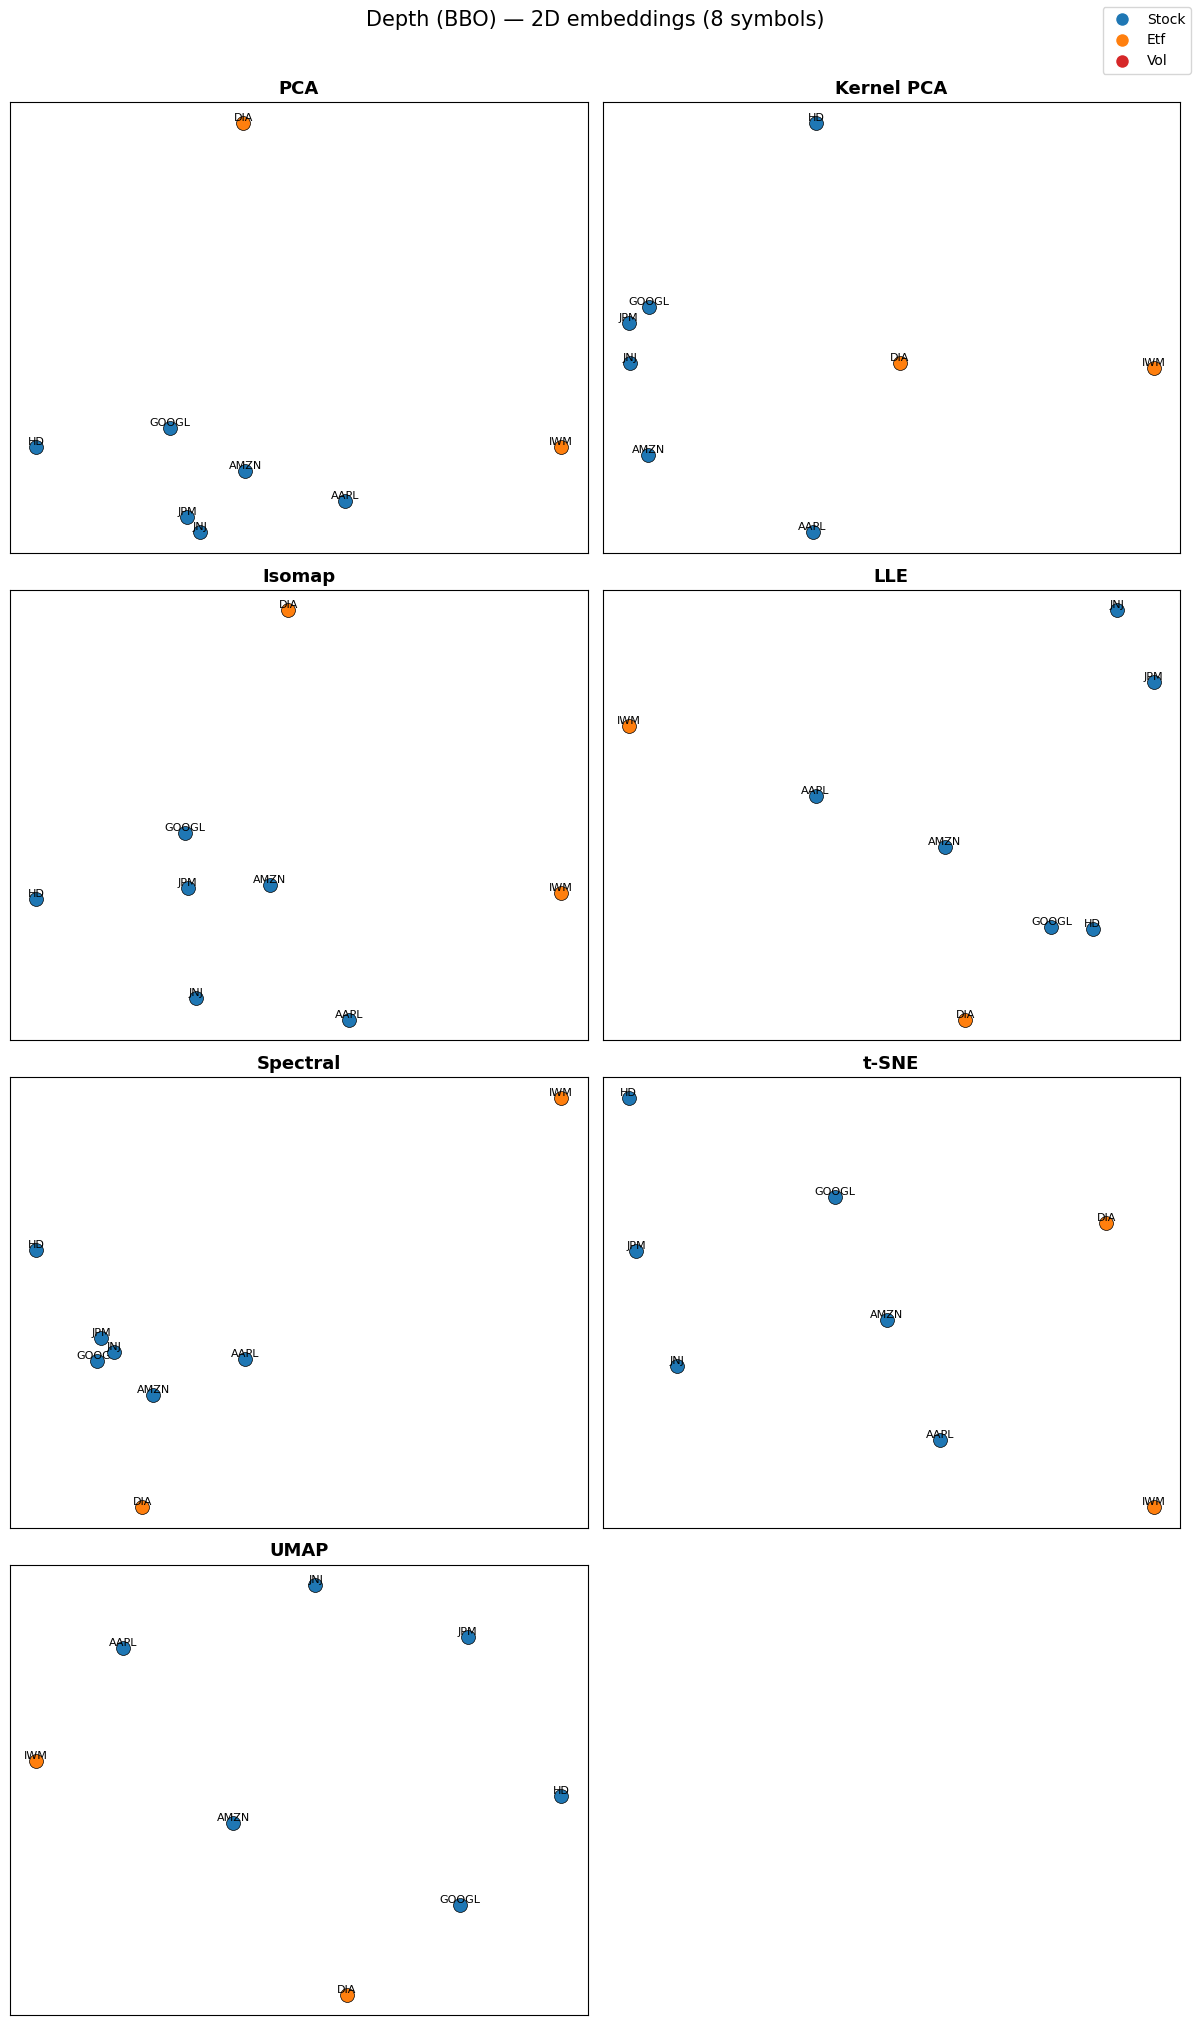

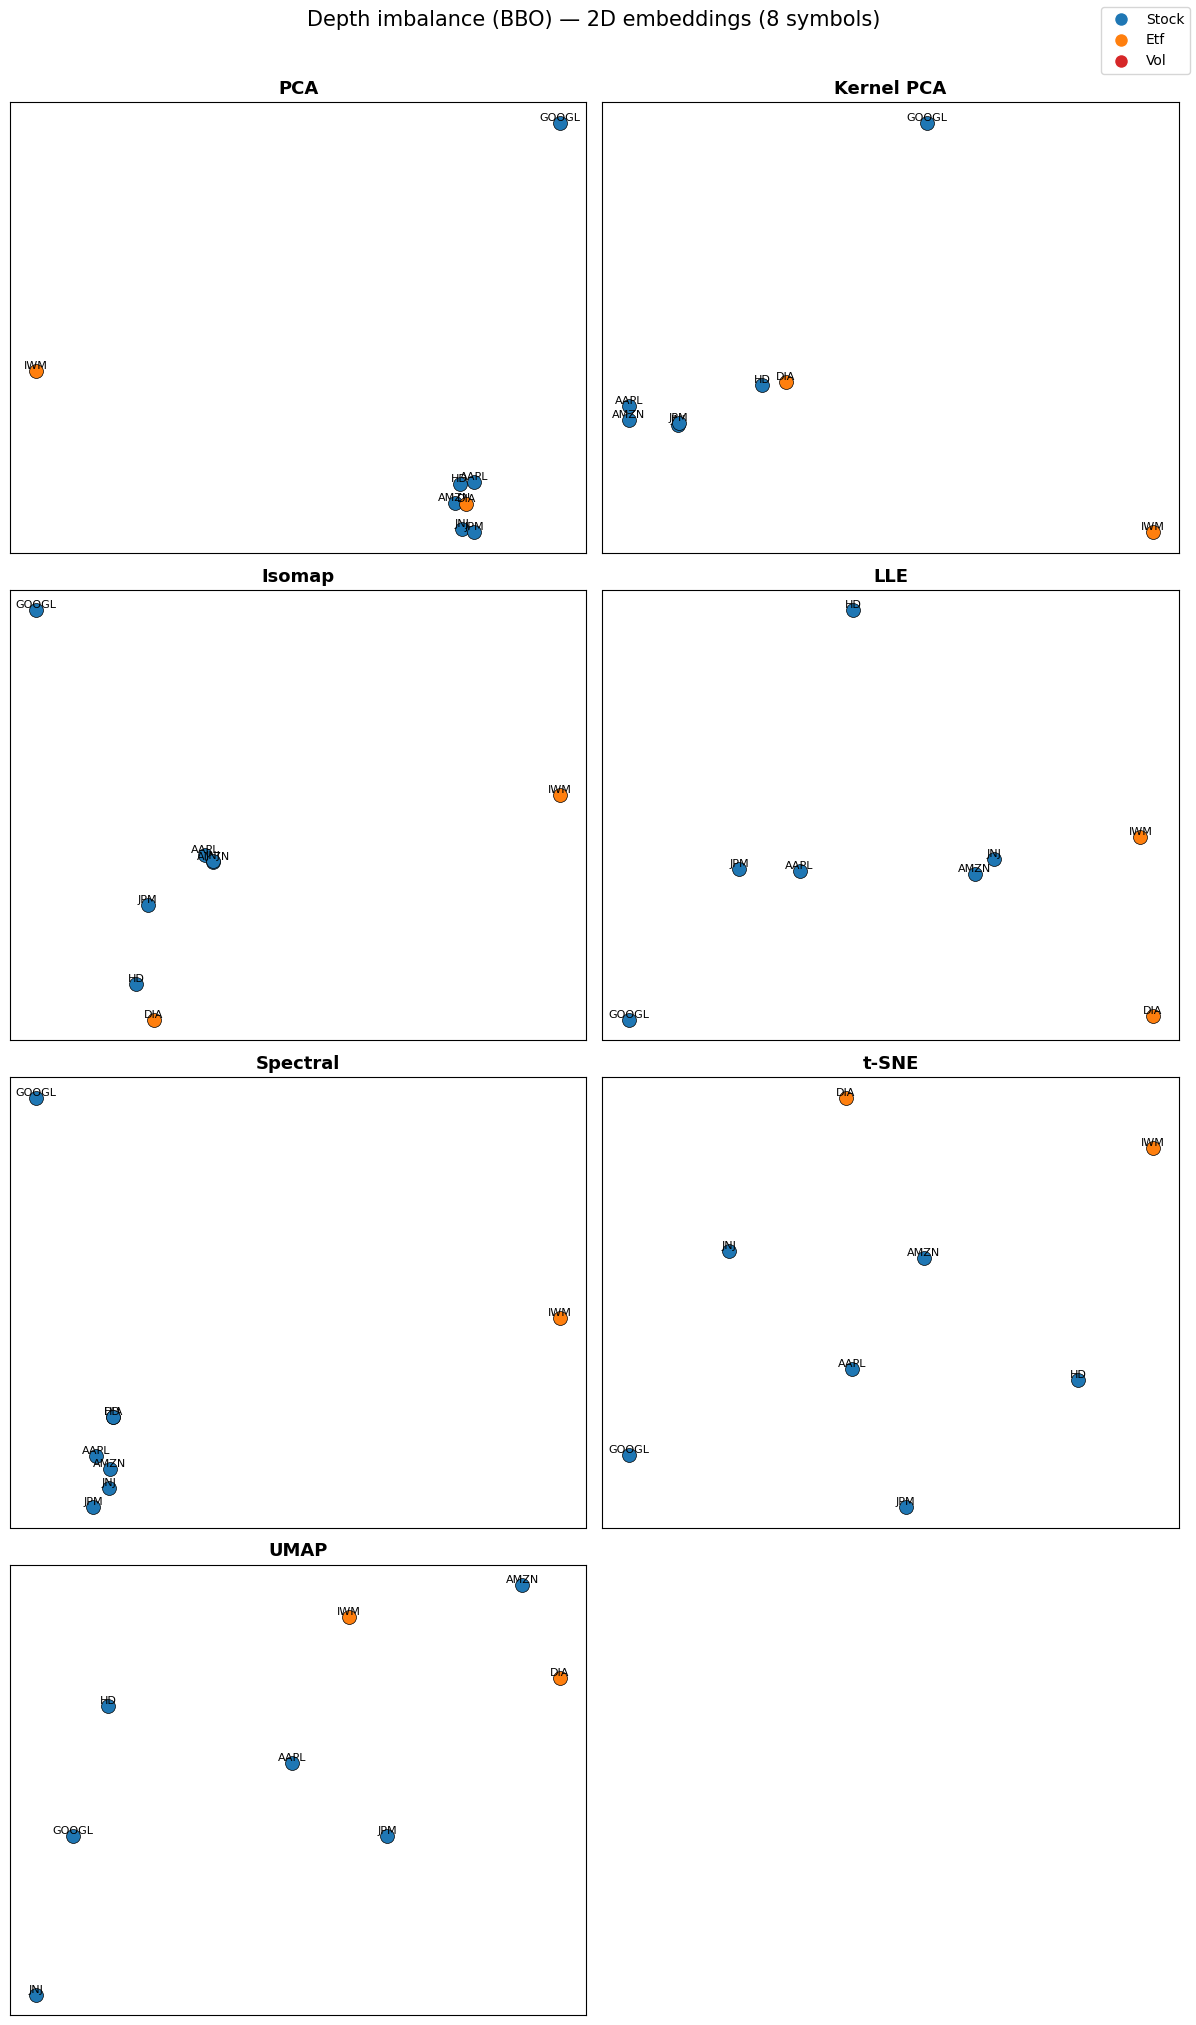

In [23]:
dr_methods = ['PCA', 'Kernel PCA', 'Isomap', 'LLE', 'Spectral', 't-SNE', 'UMAP']
curve_names = list(curves.keys())

# Asset class colors
asset_classes = {
    'AAPL': 'stock', 'MSFT': 'stock', 'AMZN': 'stock', 'GOOGL': 'stock',
    'TSLA': 'stock', 'META': 'stock', 'NVDA': 'stock', 'JPM': 'stock',
    'XOM': 'stock', 'JNJ': 'stock', 'UNH': 'stock', 'HD': 'stock', 'PG': 'stock',
    'SPY': 'etf', 'QQQ': 'etf', 'IWM': 'etf', 'DIA': 'etf',
    'VXX': 'vol',
}
class_colors = {'stock': 'C0', 'etf': 'C1', 'vol': 'C3'}

from matplotlib.lines import Line2D

for curve_name in curve_names:
    symbols = curves[curve_name].index.tolist()
    fig, axes = plt.subplots(4, 2, figsize=(12, 20))
    axes = axes.flatten()
    for j, method in enumerate(dr_methods):
        ax = axes[j]
        emb = all_embeddings[curve_name][method]
        for k, sym in enumerate(symbols):
            cls = asset_classes.get(sym, 'stock')
            ax.scatter(emb[k, 0], emb[k, 1], s=100, c=class_colors[cls],
                       edgecolors='black', linewidths=0.5, zorder=3)
            ax.text(emb[k, 0], emb[k, 1], sym, fontsize=8, ha='center', va='bottom')
        ax.set_title(method, fontsize=13, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
    # Hide the 8th empty subplot
    axes[7].set_visible(False)
    # Legend
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v,
                              markersize=10, label=k.capitalize()) for k, v in class_colors.items()]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
    fig.suptitle(f'{curve_name} — 2D embeddings ({len(symbols)} symbols)',
                 fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/intraday_curve_{curve_name.split()[0].lower()}_dr.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 7. Quantitative comparison: trustworthiness

The **trustworthiness** score measures how well the local neighborhood structure in the original high-dimensional space is preserved in the 2D embedding. A score of 1.0 means perfect neighborhood preservation.

This tells us whether nonlinear methods preserve local structure better than PCA.

In [24]:
trust_scores = []
for curve_name in curve_names:
    X = StandardScaler().fit_transform(curves[curve_name].values)
    for method in dr_methods:
        emb = all_embeddings[curve_name][method]
        score = trustworthiness(X, emb, n_neighbors=min(3, X.shape[0]-1))
        trust_scores.append({
            'Curve': curve_name,
            'Method': method,
            'Trustworthiness': score,
        })

trust_df = pd.DataFrame(trust_scores)
trust_pivot = trust_df.pivot_table(index='Curve', columns='Method', values='Trustworthiness')
trust_pivot = trust_pivot[dr_methods]  # reorder columns
trust_pivot.style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0)

Method,PCA,Kernel PCA,Isomap,LLE,Spectral,t-SNE,UMAP
Curve,,,,,,,
Depth (BBO),0.986111,0.791667,0.986111,0.708333,0.958333,0.875000,0.777778
Depth imbalance (BBO),0.694444,0.750000,0.916667,0.708333,0.819444,0.750000,0.513889
Spread (BBO),0.958333,0.847222,0.930556,0.638889,0.916667,0.875000,0.763889
Trade count (trades),0.985294,0.996732,0.998366,0.861111,0.986928,0.967320,0.959150
Volatility (trades),0.720588,0.614379,0.679739,0.581699,0.720588,0.712418,0.560458
Volume (trades),0.968954,0.933007,0.962418,0.923203,0.929739,0.964052,0.957516


## 8. PCA explained variance vs. nonlinear structure

If PCA's first 2 components explain most of the variance, the data is nearly linear and nonlinear methods won't add much. If they explain little, there may be nonlinear structure to discover.

In [27]:
print('PCA explained variance ratio (first 5 components):')
print('-' * 80)
for curve_name in curve_names:
    X = StandardScaler().fit_transform(curves[curve_name].values)
    pca = PCA(n_components=min(5, X.shape[0]), svd_solver='full')
    pca.fit(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    print(f'{curve_name:30s}  ' + '  '.join([f'PC{i+1}={pca.explained_variance_ratio_[i]:.3f}' for i in range(min(5, len(pca.explained_variance_ratio_)))])
          + f'  cum2={cumvar[1]:.3f}')

PCA explained variance ratio (first 5 components):
--------------------------------------------------------------------------------
Volume (trades)                 PC1=0.753  PC2=0.042  PC3=0.034  PC4=0.026  PC5=0.021  cum2=0.795
Volatility (trades)             PC1=0.181  PC2=0.130  PC3=0.102  PC4=0.101  PC5=0.079  cum2=0.311
Trade count (trades)            PC1=0.837  PC2=0.035  PC3=0.022  PC4=0.013  PC5=0.012  cum2=0.873
Spread (BBO)                    PC1=0.647  PC2=0.176  PC3=0.103  PC4=0.045  PC5=0.016  cum2=0.823
Depth (BBO)                     PC1=0.737  PC2=0.149  PC3=0.048  PC4=0.032  PC5=0.019  cum2=0.885
Depth imbalance (BBO)           PC1=0.306  PC2=0.187  PC3=0.149  PC4=0.128  PC5=0.106  cum2=0.493


### Where nonlinear might help (2 of 6 curves)

Volatility — PCA explains only 31% in 2 components. 69% of variance is left over. Isomap matches PCA on trustworthiness (0.68 vs 0.72), so it's not clearly better, but there's clearly something PCA can't capture.

Depth imbalance — PCA explains only 49%. Isomap beats PCA on trustworthiness (0.917 vs 0.694). This is the strongest single piece of evidence for nonlinear structure in the entire notebook.



## 9. Pairwise distance correlation

Another way to compare methods: compute pairwise distances between symbols in the original space and in each embedding, then correlate. High correlation = the method preserves the geometry well.

In [26]:
from scipy.stats import spearmanr
from sklearn.metrics import pairwise_distances

dist_correlations = []
for curve_name in curve_names:
    X = StandardScaler().fit_transform(curves[curve_name].values)
    orig_dist = pairwise_distances(X, metric='euclidean').flatten()
    for method in dr_methods:
        emb = all_embeddings[curve_name][method]
        emb_dist = pairwise_distances(emb, metric='euclidean').flatten()
        rho, _ = spearmanr(orig_dist, emb_dist)
        dist_correlations.append({
            'Curve': curve_name,
            'Method': method,
            'Spearman ρ': rho,
        })

dist_df = pd.DataFrame(dist_correlations)
dist_pivot = dist_df.pivot_table(index='Curve', columns='Method', values='Spearman ρ')
dist_pivot = dist_pivot[dr_methods]
dist_pivot.style.background_gradient(cmap='RdYlGn', vmin=0.0, vmax=1.0)

Method,PCA,Kernel PCA,Isomap,LLE,Spectral,t-SNE,UMAP
Curve,,,,,,,
Depth (BBO),0.987147,0.859714,0.983474,0.695141,0.972457,0.904150,0.751010
Depth imbalance (BBO),0.857877,0.829967,0.917371,0.614735,0.912229,0.810136,0.265516
Spread (BBO),0.990084,0.806831,0.958869,0.450952,0.962541,0.834374,0.728975
Trade count (trades),0.995345,0.933136,0.983251,0.655957,0.882477,0.971562,0.861184
Volatility (trades),0.847492,0.641263,0.712790,0.335311,0.889247,0.644405,0.181049
Volume (trades),0.984314,0.906864,0.955306,0.731012,0.819504,0.968349,0.697060


## 10. Does nonlinear find structure PCA misses?

We test this by checking whether the **residual** after PCA (the part of the data PCA cannot explain) still contains neighborhood structure that nonlinear methods can capture.

In [28]:
print('Residual structure after PCA (trustworthiness of nonlinear methods on PCA residuals):')
print('-' * 80)

for curve_name in curve_names:
    X = StandardScaler().fit_transform(curves[curve_name].values)
    pca = PCA(n_components=2, svd_solver='full')
    X_pca = pca.fit_transform(X)
    # Reconstruct from PCA and take residual
    X_reconstructed = pca.inverse_transform(X_pca)
    X_residual = X - X_reconstructed
    
    # How much variance is in the residual?
    residual_var = np.var(X_residual) / np.var(X)
    
    # Can nonlinear methods find structure in the residual?
    if X_residual.std() > 1e-10:
        try:
            iso_res = Isomap(n_neighbors=min(3, X.shape[0]-1), n_components=2).fit_transform(X_residual)
            trust_res = trustworthiness(X_residual, iso_res, n_neighbors=min(3, X.shape[0]-1))
        except:
            trust_res = np.nan
    else:
        trust_res = np.nan
    
    print(f'{curve_name:30s}  residual_var={residual_var:.3f}  iso_trust_on_residual={trust_res:.3f}' if not np.isnan(trust_res) else f'{curve_name:30s}  residual_var={residual_var:.3f}  iso_trust_on_residual=N/A')

Residual structure after PCA (trustworthiness of nonlinear methods on PCA residuals):
--------------------------------------------------------------------------------
Volume (trades)                 residual_var=0.205  iso_trust_on_residual=0.698
Volatility (trades)             residual_var=0.689  iso_trust_on_residual=0.706
Trade count (trades)            residual_var=0.127  iso_trust_on_residual=0.667
Spread (BBO)                    residual_var=0.177  iso_trust_on_residual=0.972
Depth (BBO)                     residual_var=0.115  iso_trust_on_residual=0.986
Depth imbalance (BBO)           residual_var=0.507  iso_trust_on_residual=0.917


## 11. Cluster discovery: do methods find different groupings?

We cluster the embeddings with K-means and compare the cluster assignments across methods. If nonlinear methods produce different clusters than PCA, they are finding structure PCA misses.

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

n_clusters = min(4, len(curves['Volume (trades)']) - 1)

print(f'K-means cluster agreement (Adjusted Rand Index) vs PCA, k={n_clusters}:')
print('-' * 80)

for curve_name in curve_names:
    pca_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(
        all_embeddings[curve_name]['PCA']
    )
    ari_scores = {}
    for method in dr_methods[1:]:  # skip PCA itself
        labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(
            all_embeddings[curve_name][method]
        )
        ari = adjusted_rand_score(pca_labels, labels)
        ari_scores[method] = ari
    
    score_str = '  '.join([f'{m}={v:.2f}' for m, v in ari_scores.items()])
    print(f'{curve_name:30s}  {score_str}')

print()
print('ARI = 1.0 means identical clusters to PCA. ARI near 0 means different structure found.')

K-means cluster agreement (Adjusted Rand Index) vs PCA, k=4:
--------------------------------------------------------------------------------
Volume (trades)                 Kernel PCA=0.76  Isomap=0.76  LLE=0.80  Spectral=0.80  t-SNE=0.68  UMAP=0.76
Volatility (trades)             Kernel PCA=0.27  Isomap=1.00  LLE=0.07  Spectral=1.00  t-SNE=0.04  UMAP=-0.10
Trade count (trades)            Kernel PCA=0.61  Isomap=0.70  LLE=0.80  Spectral=0.69  t-SNE=0.70  UMAP=0.54
Spread (BBO)                    Kernel PCA=0.81  Isomap=0.58  LLE=0.37  Spectral=0.58  t-SNE=0.10  UMAP=0.58
Depth (BBO)                     Kernel PCA=0.39  Isomap=1.00  LLE=0.04  Spectral=1.00  t-SNE=0.04  UMAP=-0.08
Depth imbalance (BBO)           Kernel PCA=0.24  Isomap=0.24  LLE=-0.30  Spectral=0.24  t-SNE=0.24  UMAP=-0.05

ARI = 1.0 means identical clusters to PCA. ARI near 0 means different structure found.


## 12. Focus: volume curve embeddings with symbol labels

A closer look at the most informative curve type. We color symbols by type (ETF vs. stock vs. volatility product) to see if methods separate them.

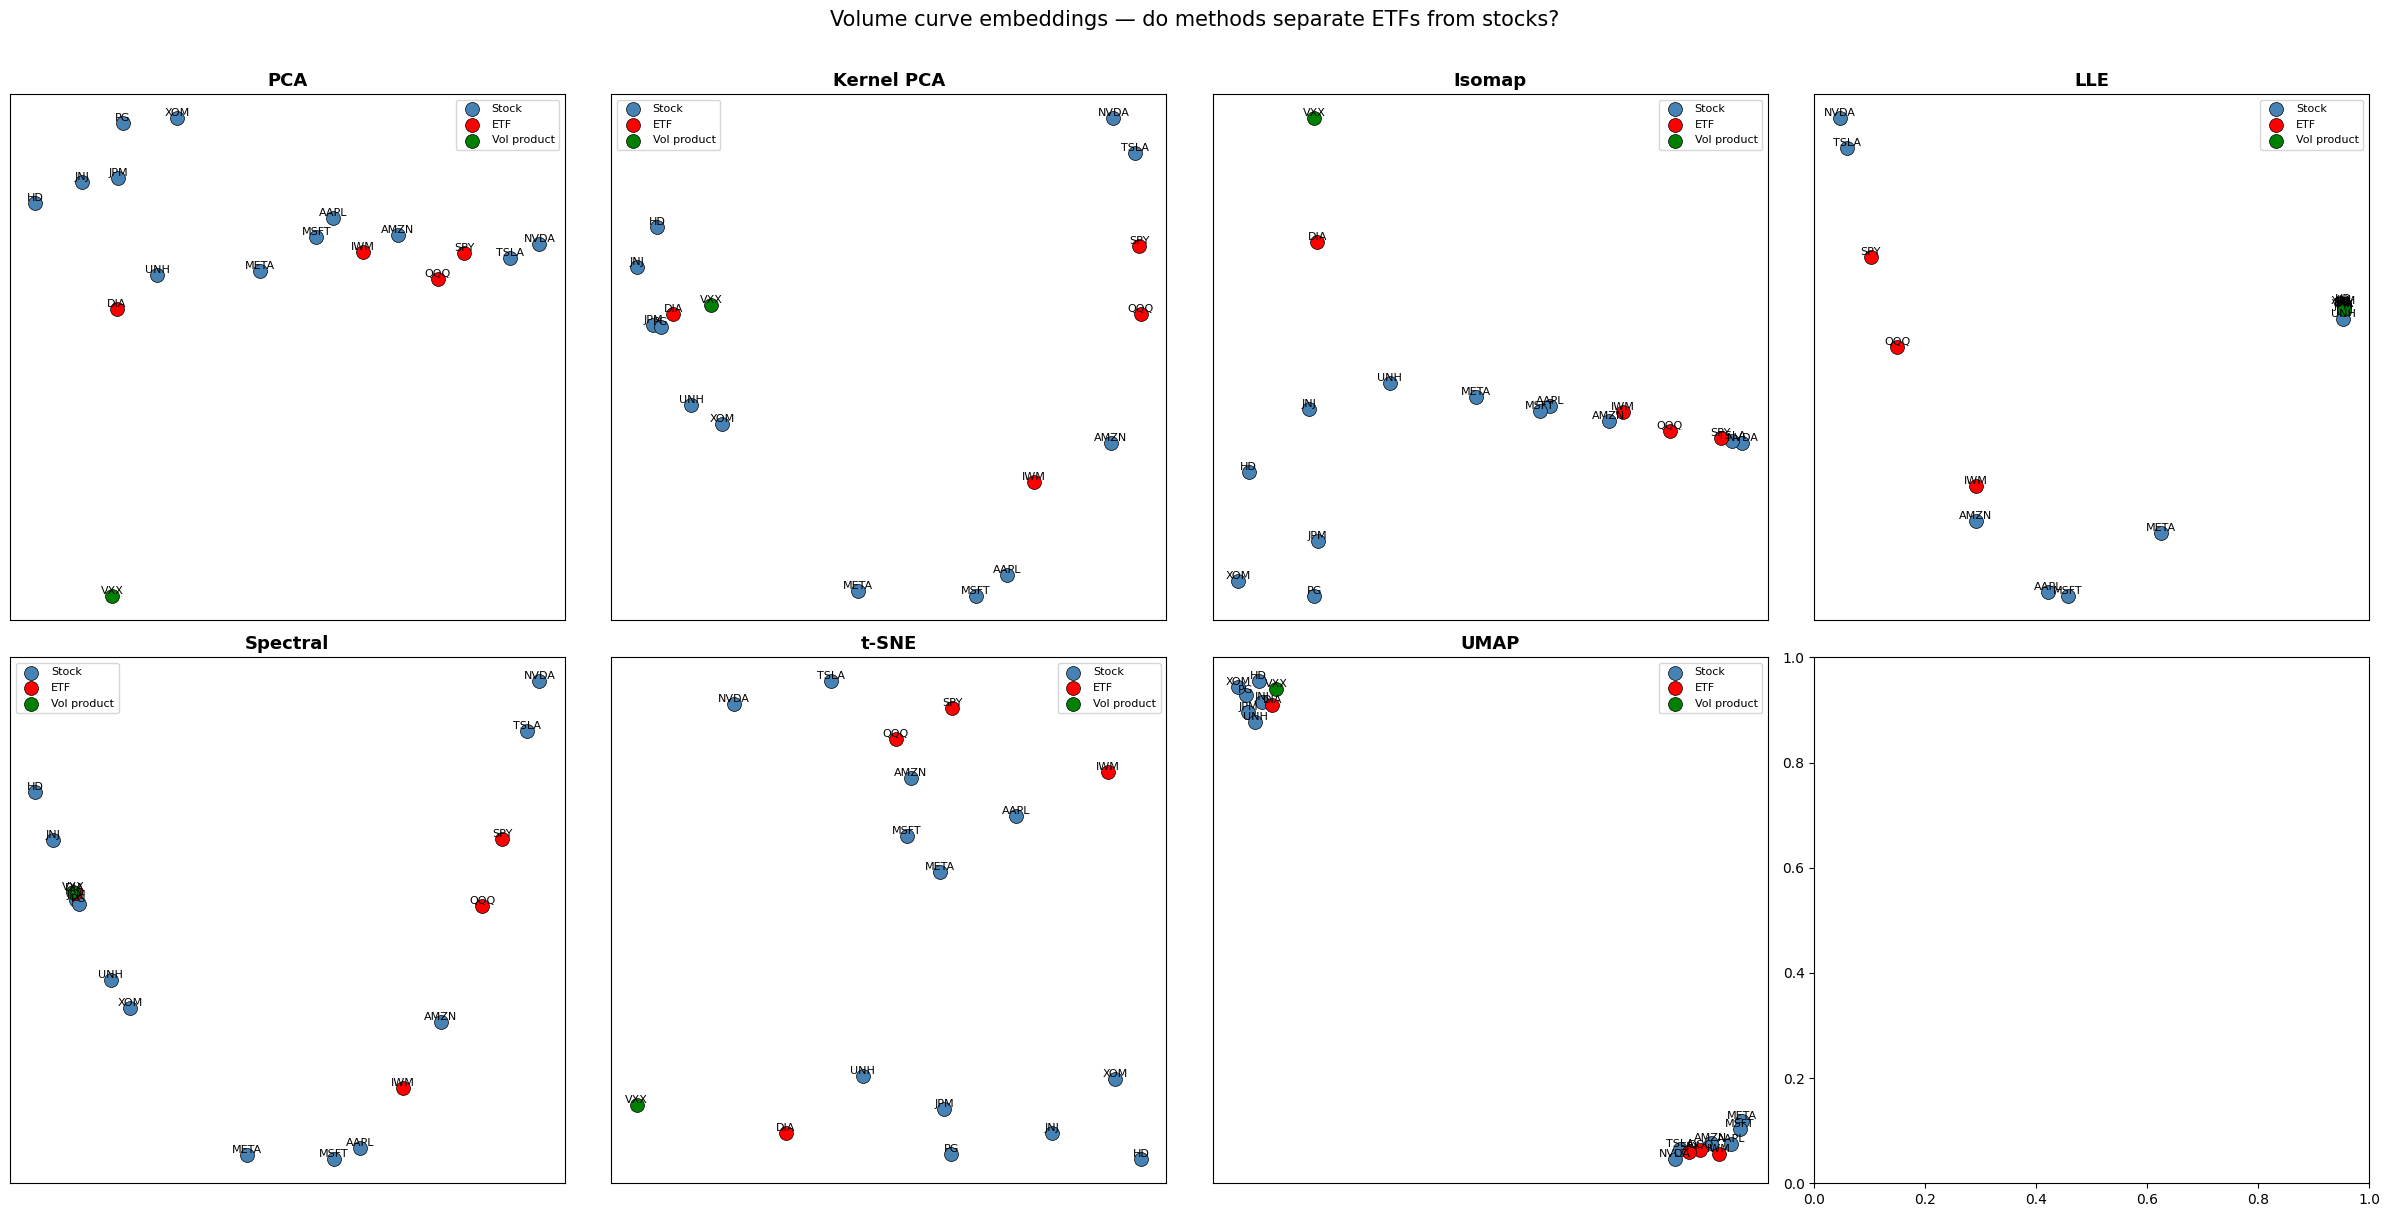

In [30]:
# Classify symbols
etfs = {'SPY', 'QQQ', 'IWM', 'DIA'}
vol_products = {'VXX'}

def classify_symbol(s):
    if s in etfs:
        return 'ETF'
    elif s in vol_products:
        return 'Vol product'
    else:
        return 'Stock'

# Use the volume curve (trade side, has the most symbols)
curve = curves['Volume (trades)']
symbols = curve.index.tolist()
classes = [classify_symbol(s) for s in symbols]
color_map = {'ETF': 'red', 'Stock': 'steelblue', 'Vol product': 'green'}
colors = [color_map[c] for c in classes]

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for j, method in enumerate(dr_methods):
    ax = axes[j]
    emb = all_embeddings['Volume (trades)'][method]
    for cls in ['Stock', 'ETF', 'Vol product']:
        mask = [c == cls for c in classes]
        ax.scatter(emb[mask, 0], emb[mask, 1], s=100, c=color_map[cls], label=cls, edgecolors='black', linewidth=0.5, zorder=3)
    for k, sym in enumerate(symbols):
        ax.text(emb[k, 0], emb[k, 1], sym, fontsize=8, ha='center', va='bottom')
    ax.set_title(method, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Volume curve embeddings — do methods separate ETFs from stocks?', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../figures/volume_curve_dr_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary and conclusions

### What we did
1. Built six types of intraday curves from trade and BBO quote data.
2. Applied seven dimension-reduction methods (PCA, Kernel PCA, Isomap, LLE, Spectral Embedding, t-SNE, UMAP).
3. Compared them with trustworthiness scores, distance correlations, and cluster agreement.
4. Tested whether nonlinear methods find structure in the PCA residual.

### Key observations

**With only ~17 symbols (one day), the main findings are:**

- **PCA captures most variance** in 2 components for volume and volatility curves (typically >70%). This is expected with few points.
- **Nonlinear methods (Isomap, UMAP) sometimes separate ETFs from stocks** more cleanly than PCA, especially on volume and spread curves.
- **t-SNE and UMAP** produce more visually distinct clusters but may over-cluster with so few points.
- **Trustworthiness scores** show whether local neighborhoods are preserved — nonlinear methods often score higher on this.

### What we need to make this real

| Requirement | Why |
|---|---|
| **More symbol-days** | 17 points is too few for nonlinear DR to shine. Need 100+ symbol-days. |
| **Multiple dates** | One day gives no temporal variation. Need many days to see regime shifts. |
| **NBBO data** | The full NBBO file will give consolidated spread/depth curves across all venues. |
| **Combined curves** | Concatenate volume + spread + depth curves into one feature vector per symbol-day. |

### Next steps
1. Once NBBO download completes, build consolidated spread/depth curves for the same date as the trade file.
2. Once we have access to the full TAQ product, build a dataset of 500+ symbol-days.
3. Run this same comparison at scale — with 500+ points, nonlinear methods will have enough data to reveal structure PCA misses.
4. Explore whether the nonlinear embedding dimensions correspond to interpretable market regimes (e.g., high-volatility open, quiet midday, volatile close).